<a href="https://colab.research.google.com/github/santiagomarin11/Fisica_Computacional_1/blob/main/Laboratorio_opcional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Punto 1

In [41]:
# @title
import matplotlib.tri as tri
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Configuración de matplotlib
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 6)

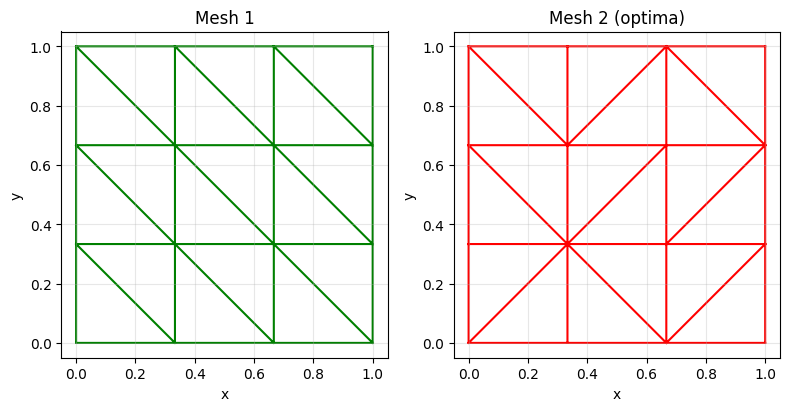

In [42]:
# Nodos de la malla (9 nodos en una cuadrícula 3x3)
x_coords = np.linspace(0, 1, 4)
y_coords = np.linspace(0, 1, 4)
X, Y = np.meshgrid(x_coords, y_coords)
nodes = np.column_stack((X.ravel(), Y.ravel()))
# Elementos (8 triángulos dividiendo cada cuadrado en 2)
elements = np.array([
    [0,4,1], [1,5,2], [1,4,5],
    [2,6,5], [2,6,3], [6,7,3],
    [4,8,5], [5,9,6], [5,8,9],
    [6,10,7], [7,10,11],
    [8,12,9], [9,13,10], [9,12,13],
    [10,14,11], [10,13,14], [11,14,15],[6,10,9]
])

# Número de nodos y elementos
n_nodes = len(nodes)
n_elements = len(elements)
triang2 = tri.Triangulation(nodes[:,0], nodes[:,1])
elements2 = triang2.triangles

# Visualización de la malla
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# Mesh 1
axs[0].triplot(nodes[:, 0], nodes[:, 1], elements, 'g-')
axs[0].set_title('Mesh 1')
axs[0].set_aspect('equal')
axs[0].grid(True, alpha=0.3)

# Mesh 2
axs[1].triplot(nodes[:, 0], nodes[:, 1], elements2, 'r-')
axs[1].set_title('Mesh 2 (optima)')
axs[1].set_aspect('equal')
axs[1].grid(True, alpha=0.3)

for ax in axs:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

In [43]:
def triangle_area(nodes_elem):
    x1, y1 = nodes_elem[0]
    x2, y2 = nodes_elem[1]
    x3, y3 = nodes_elem[2]
    return 0.5 * abs((x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1))
def element_stiffness(nodes_elem):
    x1, y1 = nodes_elem[0]
    x2, y2 = nodes_elem[1]
    x3, y3 = nodes_elem[2]

    # Área
    A = np.abs(triangle_area(nodes_elem))

    # Coeficientes b y c
    b1 = y2 - y3
    b2 = y3 - y1
    b3 = y1 - y2
    c1 = x3 - x2
    c2 = x1 - x3
    c3 = x2 - x1

    # Matriz de rigidez elemental
    Ke = np.array([
        [b1*b1 + c1*c1, b1*b2 + c1*c2, b1*b3 + c1*c3],
        [b2*b1 + c2*c1, b2*b2 + c2*c2, b2*b3 + c2*c3],
        [b3*b1 + c3*c1, b3*b2 + c3*c2, b3*b3 + c3*c3]
    ])/(4*A)

    return Ke

K = lil_matrix((n_nodes, n_nodes))
K2 = lil_matrix((n_nodes, n_nodes))


def assemble_stiffness(nodes, elements):
    n_nodes = len(nodes)
    K = np.zeros((n_nodes, n_nodes))

    for elem in elements:
        Ke = element_stiffness(nodes[elem])
        K[np.ix_(elem, elem)] += Ke   # 🔥 clean assembly

    return K
K=assemble_stiffness(nodes, elements)
K2=assemble_stiffness(nodes, elements2)


In [44]:
b = np.zeros(n_nodes)
b2 = np.zeros(n_nodes)
def g(x,y):
  return 1.0
def assemble_load(nodes, elements, f=1.0):
    n_nodes = len(nodes)
    b = np.zeros(n_nodes)

    for elem in elements:
        nodes_elem = nodes[elem]
        A = triangle_area(nodes_elem)

        # for constant f
        Fe = (A/3) * f * np.ones(3)

        for i in range(3):
            b[elem[i]] += Fe[i]

    return b

b = assemble_load(nodes, elements)
b2 = assemble_load(nodes, elements2)


In [45]:
boundary_nodes = []
for i, (x, y) in enumerate(nodes):
    if x == 0 or x == 1 or y == 0 or y == 1:
        boundary_nodes.append(i)


# Aplicar condiciones de frontera Dirichlet u=0 en nodos del borde
for i in boundary_nodes:
    K[i, :] = 0
    K[i, i] = 1
    b[i] = 0
    K2[i, :] = 0
    K2[i, i] = 1
    b2[i] = 0


In [46]:
from numpy.linalg import solve

u  = solve(K, b)
u2 = solve(K2, b2)

Soluciones con un mayado de 16 nodos, Usando la funcion optimisada y escribiendo los triangulos a mano

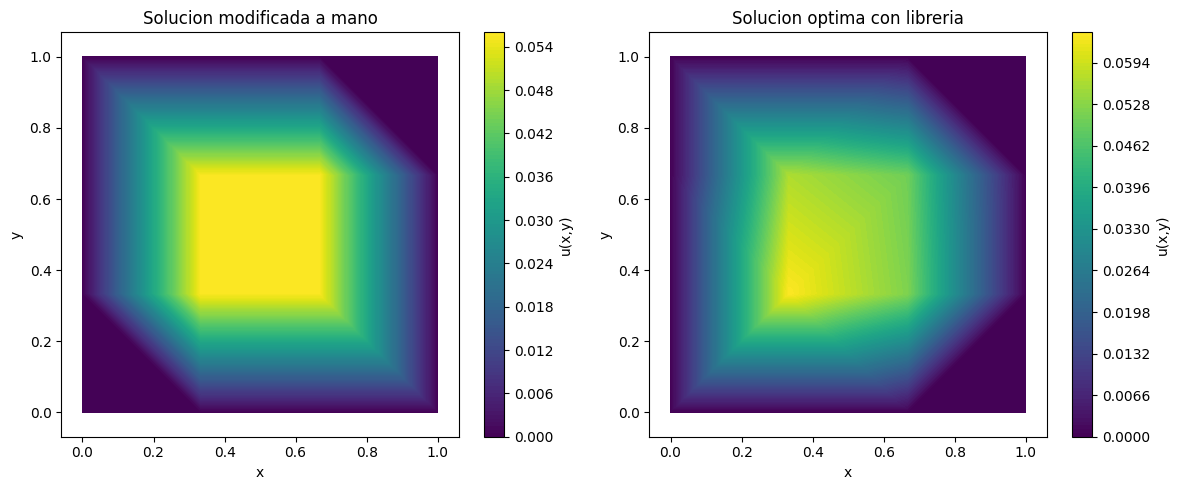

In [47]:
# @title
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Mesh 1 solution
c1 = axs[0].tricontourf(
    nodes[:, 0], nodes[:, 1],
    elements, u,
    levels=120,
    cmap='viridis'
)
fig.colorbar(c1, ax=axs[0], label='u(x,y)')
axs[0].set_title('Solucion modificada a mano')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].axis('equal')

# Mesh 2 solution
c2 = axs[1].tricontourf(
    nodes[:, 0], nodes[:, 1],
    elements2, u2,
    levels=120,
    cmap='viridis'
)
fig.colorbar(c2, ax=axs[1], label='u(x,y)')
axs[1].set_title('Solucion optima con libreria')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].axis('equal')

plt.tight_layout()
plt.show()

# Punto 2

In [48]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

x3 = np.linspace(0, 2*np.pi, 100)
y3 = np.linspace(0, 2*np.pi, 100)

X3, Y3 = np.meshgrid(x3, y3)

# Coordenadas de cada nodo en orden
nodos3 = np.column_stack((X3.ravel(), Y3.ravel()))

# Triangulación usando nodos3
triang3 = tri.Triangulation(nodos3[:, 0], nodos3[:, 1])
elements3 = triang3.triangles


Luego, los elementos almacenan los triángulos como listas de tres índices: $[i, j, k]$.  
Cada uno de estos índices corresponde al número de un nodo en el vector `nodes`.

Las coordenadas del triángulo se obtienen accediendo a:
$$
\text{nodes}[i], \quad \text{nodes}[j], \quad \text{nodes}[k],
$$
donde cada entrada de `nodes` contiene las coordenadas cartesianas $(x, y)$ del nodo correspondiente.

A cada nodo del elemento se le asocia una función de forma $N_1, N_2, N_3$, definidas localmente sobre el triángulo.  
Con estas funciones se obtiene el sistema elemental:

$$
\begin{pmatrix}
\int_{\Omega_e} \nabla N_1 \cdot \nabla N_1 \, d\Omega &
\int_{\Omega_e} \nabla N_1 \cdot \nabla N_2 \, d\Omega &
\int_{\Omega_e} \nabla N_1 \cdot \nabla N_3 \, d\Omega \\
\int_{\Omega_e} \nabla N_2 \cdot \nabla N_1 \, d\Omega &
\int_{\Omega_e} \nabla N_2 \cdot \nabla N_2 \, d\Omega &
\int_{\Omega_e} \nabla N_2 \cdot \nabla N_3 \, d\Omega \\
\int_{\Omega_e} \nabla N_3 \cdot \nabla N_1 \, d\Omega &
\int_{\Omega_e} \nabla N_3 \cdot \nabla N_2 \, d\Omega &
\int_{\Omega_e} \nabla N_3 \cdot \nabla N_3 \, d\Omega
\end{pmatrix}
\begin{pmatrix}
\alpha_1 \\
\alpha_2 \\
\alpha_3
\end{pmatrix}
=
\begin{pmatrix}
\int_{\Omega_e} N_1 f \, d\Omega \\
\int_{\Omega_e} N_2 f \, d\Omega \\
\int_{\Omega_e} N_3 f \, d\Omega
\end{pmatrix}
$$

Donde Alpha es el valor de la solucion en los tres nodos del elemento

Mediante un cambio de coordenadas, se obtiene una expresión explícita para la matriz de rigidez del elemento.  
Definiendo:

$$
\begin{aligned}
b_1 &= (y_2 - y_3), & c_1 &= (x_3 - x_2) \\
b_2 &= (y_3 - y_1), & c_2 &= (x_1 - x_3) \\
b_3 &= (y_1 - y_2), & c_3 &= (x_2 - x_1)
\end{aligned}
$$

la matriz de rigidez elemental está dada por:

$$
K_e = \frac{1}{4A}
\begin{pmatrix}
b_1^2 + c_1^2 & b_1 b_2 + c_1 c_2 & b_1 b_3 + c_1 c_3 \\
b_2 b_1 + c_2 c_1 & b_2^2 + c_2^2 & b_2 b_3 + c_2 c_3 \\
b_3 b_1 + c_3 c_1 & b_3 b_2 + c_3 c_2 & b_3^2 + c_3^2
\end{pmatrix}
$$

donde $A$ es el área del triángulo:

$$
A = \frac{1}{2} \left| (x_2 - x_1)(y_3 - y_1) - (x_3 - x_1)(y_2 - y_1) \right|
= \frac{1}{2} \left| -c_3 b_2 + c_2 b_3 \right|.
$$



$$
f(x,y) = \sin(\pi x)\,\sin(\pi y)\,N_i(x,y)
$$

Note que esta función es **continua e infinitamente diferenciable** ($C^\infty$).  
Por lo tanto, mediante una expansión en serie de Taylor, puede aproximarse localmente por una función lineal en un entorno pequeño de un punto $(x_0, y_0)$:

$$
f(x,y) \approx f(x_0,y_0)
+ \frac{\partial f}{\partial x}(x_0,y_0)(x - x_0)
+ \frac{\partial f}{\partial y}(x_0,y_0)(y - y_0)
$$

Esto implica que, en regiones suficientemente pequeñas (como los elementos en el método de elementos finitos), la función se comporta aproximadamente de manera lineal.

$$
b_i = \int_{\Omega_e} f(x,y)\, d\Omega
$$

Bajo esta hipótesis, la integral puede aproximarse mediante una cuadratura gaussiana de un punto:

$$
b_i \approx f(x_c, y_c)\, A_e
$$

donde $(x_c, y_c)$ es el centroide del triángulo y $A_e$ su área.

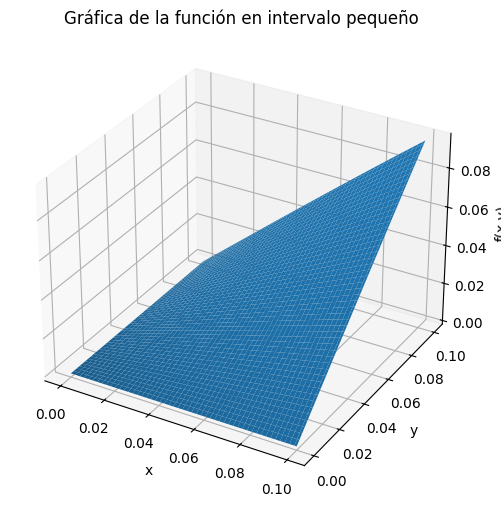

In [49]:
# @title
# dominio
x = np.linspace(0, 0.1, 100)
y = np.linspace(0, 0.1, 100)

X, Y = np.meshgrid(x, y)

# función
Z = np.sin(np.pi * X) * np.sin(np.pi * Y)

# gráfica
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Gráfica de la función en intervalo pequeño')
plt.show()

Luego, la matriz global se obtiene ensamblando las matrices elementales $K_e$.  
Cada $K_e$ se ubica en las posiciones de la matriz global asociadas a los nodos del elemento, para que cuadren con sus posiciones respecto al vector $b$ total.  
Si varios elementos comparten nodos, sus contribuciones se suman en las mismas entradas de la matriz global.

In [50]:
def f(x,y):
  return np.sin(np.pi * x) * np.sin(np.pi * y)
def centroide(nodes_elem):
    xc = np.mean(nodes_elem[:, 0])
    yc = np.mean(nodes_elem[:, 1])
    return xc, yc

In [51]:
def assemble_load(nodes, elements, f=f):
    n_nodes = len(nodes)
    b = np.zeros(n_nodes)

    for elem in elements:
        nodes_elem = nodes[elem]
        A = triangle_area(nodes_elem)

        # for constant f
        Fe = (A/3) * f(centroide(nodes)[0],centroide(nodes)[1]) * np.ones(3)

        for i in range(3):
            b[elem[i]] += Fe[i]

    return b

In [52]:
b3 = assemble_load(nodos3, elements3)
K3= assemble_stiffness(nodos3, elements3)
boundary_nodes3 = []
for i, (x, y) in enumerate(nodos3):
    if x == 0 or x == 1 or y == 0 or y == 1:
        boundary_nodes3.append(i)


# Aplicar condiciones de frontera Dirichlet u=0 en nodos del borde
for i in boundary_nodes3:
    K3[i, :] = 0
    K3[i, i] = 1
    b3[i] = 0

In [53]:
U3 = solve(K3, b3)

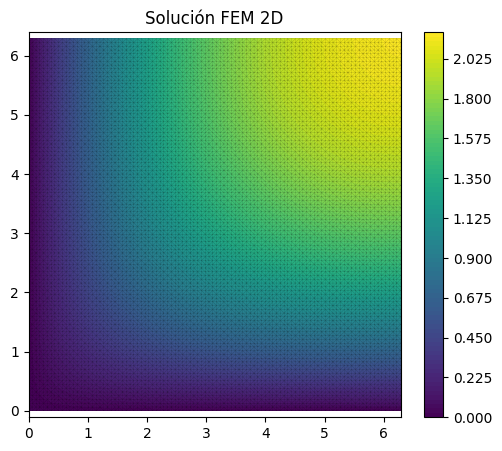

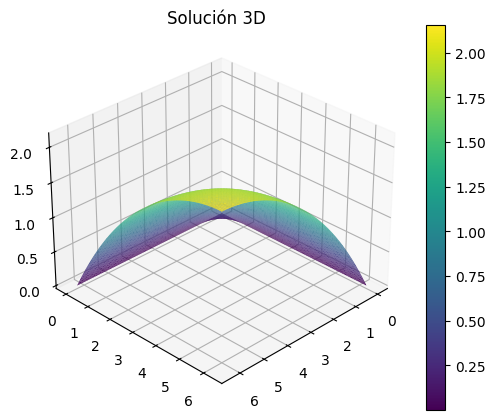

In [54]:
# 2D
plt.figure(figsize=(6,5))
plt.tricontourf(nodos3[:, 0], nodos3[:, 1], elements3, U3, levels=100, cmap='viridis')
plt.colorbar()
plt.triplot(nodos3[:, 0], nodos3[:, 1], elements3, color='k', linewidth=0.2, alpha=0.3)
plt.title('Solución FEM 2D')
plt.axis('equal')
plt.show()

# 3D
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_trisurf(nodos3[:, 0], nodos3[:, 1], U3, triangles=elements3, cmap='viridis')
fig.colorbar(surf, ax=ax)
ax.set_title('Solución 3D')
ax.view_init(30,45)
plt.show()